# CNNs and Transformers in PyTorch

Implementing CNN and Transformer architectures from scratch in PyTorch, trained on MiniImageNet and TinyStories.

**Part 1:** Custom CNN  
**Part 2:** ResNet-18 with residual blocks  
**Part 3:** Full Transformer — attention, encoder/decoder, positional encoding, and text generation

In [121]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
import random
from datasets import load_dataset
import matplotlib.pyplot as plt
import plotly
import plotly.subplots
import plotly.graph_objects
import os
import json
import re
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision.transforms as transforms

In [122]:
def set_seed(seed):
    """
    Set the seed for all random number generators
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Set random seeds for reproducible results
SEED = 42
set_seed(SEED)


if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
else:
    device = "cpu"

print(f"Using device: {device}") # Check that the current device is cuda or another GPU accelerator!

Using device: cuda


# Part 1: CNNs

Building a CNN in PyTorch using `nn.Module`, then training it on MiniImageNet.

## Custom CNN

Two conv layers followed by a linear classifier:

- Conv1: 16 channels, 3×3 kernel, stride 2, padding 1 → ReLU  
- Conv2: 16 channels, 7×7 kernel, stride 2, padding 1 → ReLU  
- Linear: flatten → num_classes

In [123]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3,stride=2,padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=7,stride=2,padding=1)
        self.linear = nn.Linear(in_features=16*54*54, out_features=num_classes)
        # Optional: You can also define your ReLU layers here if you'd like
        # Otherwise, if you decide to use F.relu you can just remove these lines
        # self.relu1 = ...
        # self.relu2 = ...

    def forward(self, x):
        conv1_out = self.conv1(x)

        relu1_out = F.relu(conv1_out)

        conv2_out = self.conv2(relu1_out)

        relu2_out = F.relu(conv2_out)

        flat = relu2_out.flatten(start_dim=1)

        out = self.linear(flat)

        return out

### Shape check

Input `(1, 3, 224, 224)` through `CNN(num_classes=10)`:

1. After conv1: `(1, 16, 112, 112)`  
2. After conv2: `(1, 16, 54, 54)`  
3. After flatten + linear: `(1, 10)`

In [124]:
x = torch.rand((1, 3, 224, 224))  # 1 image, 3 RGB channels, 224 x 224 pixels
print(f"Shape of input: {x.shape}")

res = CNN(num_classes=10)
out = res(x)
print(f"Shape of output: {out.shape}")
assert out.shape == torch.Size([1, 10]), f"Expected output shape (1, 10), but got {out.shape}"

Shape of input: torch.Size([1, 3, 224, 224])
Shape of output: torch.Size([1, 10])


## Load Data

Loading MiniImageNet from Hugging Face — a 100-class subset of ImageNet-1k with 50k training images, 10k validation, and 5k test samples.

In [125]:
# Helper function to sample a balanced subset of the dataset
def balanced_split(dataset, n_total: int, classes_to_keep: set[int] = None):
  """
  Returns a balanced subset of the dataset with `n_total` samples, equally divided among the specified classes.

  If `classes_to_keep` is provided, only samples from these classes are included, each contributing exactly (n_total // num_classes) samples.
  If not provided, all unique classes in the dataset are used.
  Assumes the dataset is a Hugging Face Dataset object with a 'label' field.

  Args:
      dataset (datasets.Dataset):
          The dataset to subsample. Must have a 'label' column.
      n_total (int):
          Total number of samples to return. Must be divisible by the number of selected classes.
      classes_to_keep (set[int], optional):
          Class labels to include in the balanced subset. Each class will have n_total // num_classes samples.
          If None, all classes in the dataset will be used.

  Returns:
      datasets.Dataset:
          A new dataset with `n_total` samples, equally distributed across the specified classes.

  Raises:
      ValueError:
          If the number of samples per class is greater than the available samples for any class,
          or if n_total is not divisible by the number of classes.
  """
  if not classes_to_keep:
    classes_to_keep = set(dataset['label'])
  n_per_class = n_total // len(classes_to_keep)

  # Dictionary of class to list of indices that correspond to that class
  cls_to_indices = {cls: [] for cls in classes_to_keep }

  # Iterate through all indices and labels in the dataset's label list
  for i, cls in enumerate(dataset['label']):
    # If this label corresponds to a class we want to keep, append it to the appropriate class's list
    if cls in cls_to_indices:
      cls_to_indices[cls].append(i)

  sampled_idxs = []
  for cls, idx_list in cls_to_indices.items():
    if len(idx_list) < n_per_class:
      # If not enough samples, include them all
      sampled_idxs.extend(idx_list)
    else:
      sampled_idxs.extend(random.sample(idx_list, k=n_per_class))

  return dataset.select(sampled_idxs)

# Load a dictionary that maps numeric class IDs to string class names
with open('imagenet_class_id_to_name.json', 'r') as file:
    class_id_to_name = json.load(file)
    class_id_to_name = {int(key): value for key, value in class_id_to_name.items()}
    print(f"All classes in the ImageNet dataset: {class_id_to_name}")

# Load the training, validataion, and test sets
mini_imagenet_train = load_dataset("timm/mini-imagenet", split="train[:10%]")
mini_imagenet_train = balanced_split(mini_imagenet_train, n_total=1000, classes_to_keep={0,1,2,3,4,5,6,7,8,9})
print(mini_imagenet_train)

mini_imagenet_val = load_dataset("timm/mini-imagenet", split="validation[:10%]")
mini_imagenet_val = balanced_split(mini_imagenet_val, n_total=200, classes_to_keep={0,1,2,3,4,5,6,7,8,9})
print(mini_imagenet_val)

All classes in the ImageNet dataset: {0: 'house_finch', 1: 'robin', 2: 'triceratops', 3: 'green_mamba', 4: 'harvestman', 5: 'toucan', 6: 'goose', 7: 'jellyfish', 8: 'nematode', 9: 'king_crab', 10: 'dugong', 11: 'Walker_hound', 12: 'Ibizan_hound', 13: 'Saluki', 14: 'golden_retriever', 15: 'Gordon_setter', 16: 'komondor', 17: 'boxer', 18: 'Tibetan_mastiff', 19: 'French_bulldog', 20: 'malamute', 21: 'dalmatian', 22: 'Newfoundland', 23: 'miniature_poodle', 24: 'white_wolf', 25: 'African_hunting_dog', 26: 'Arctic_fox', 27: 'lion', 28: 'meerkat', 29: 'ladybug', 30: 'rhinoceros_beetle', 31: 'ant', 32: 'black-footed_ferret', 33: 'three-toed_sloth', 34: 'rock_beauty', 35: 'aircraft_carrier', 36: 'ashcan', 37: 'barrel', 38: 'beer_bottle', 39: 'bookshop', 40: 'cannon', 41: 'carousel', 42: 'carton', 43: 'catamaran', 44: 'chime', 45: 'clog', 46: 'cocktail_shaker', 47: 'combination_lock', 48: 'crate', 49: 'cuirass', 50: 'dishrag', 51: 'dome', 52: 'electric_guitar', 53: 'file', 54: 'fire_screen', 55:

## Custom Dataset

Wrapping the HuggingFace dataset in a PyTorch `Dataset` class that applies image transforms and returns `(image, label)` pairs.

In [126]:
class MiniImageNetDataset(Dataset):
    def __init__(
        self,
        dataset,
        class_id_to_name: dict[int, str],
        split: str = "train",
        transform: transforms.Compose = None,
    ):
        """
        Args:
            dataset (datasets.Dataset): HuggingFace dataset object
                Each sample in the dataset has:
                - An "image" field that contains the image data
                - A "label" field that contains the numeric class ID
            class_id_to_name (dict): dictionary mapping numeric class IDs to class names
            split (str): "train" or "val" or "test"
        """
        self.split = split
        self.dataset = dataset
        self.transform = transform
        self.class_id_to_name = class_id_to_name

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        """
        Returns a single sample from the dataset at the given index.
        Args:
            index (int): index of the item to get
        Returns:
            tuple: (image, label) where image is a tensor of shape C x H x W and label is a tensor of shape 1
        """

        # Don't forget to...
        # - Cast the item and label to torch.Tensor with the correct dtype
        # - Permute the image into the shape (C, H, W)
        # - Apply the transform if it's not None
        sample = self.dataset[index]
        item = sample['image'].convert('RGB')
        if self.transform:
            item = self.transform(item)
        else:
            item = torch.tensor(np.array(item))
            item = item.permute(2,0,1)
        item = item.float()
        label = sample['label']

        return item, label

    def show_images(self, num_images: int = 10):
        """
        Visualize images in a grid layout.

        Args:
            num_images (int): Number of images to display per class

        Returns:
            tuple: (fig, ax) - Matplotlib figure and axes objects
        """
        # Make sure to call fig.show() or plt.show() to display your grid of images at the end!
        indices = random.sample(range(len(self)), num_images)
        fig, ax = plt.subplots(1, num_images, figsize=(2*num_images,3))

        for x,i in zip(ax,indices):
            sample = self.dataset[i]
            image = np.array(sample['image'])
            label = self.class_id_to_name[sample['label']]

            x.imshow(image)
            x.set_title(label)
            x.axis('off')

        fig.tight_layout()
        plt.show()

        return fig, ax

## Image Transforms

Applying resize, center crop, and normalization transforms to training and validation sets.

In [127]:
train_transform = transforms.Compose([
    transforms.Resize(256),                  # Resize the shorter side to 256
    transforms.RandomCrop(224),              # Random crop into shape 224×224
    transforms.RandomHorizontalFlip(),       # Random horizontal flip
    transforms.ToTensor(),                   # Convert to tensor, scale to [0,1], and permute into shape (C, H, W)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # Normalize
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MiniImageNetDataset(
    mini_imagenet_train,
    class_id_to_name,
    split="train",
    transform=train_transform
    )
val_dataset = MiniImageNetDataset(
    mini_imagenet_val,
    class_id_to_name,
    split="val",
    transform=val_transform
    )

Training, validation, and test `DataLoader`s with `batch_size=32` and `shuffle=True`.

In [128]:
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=32,shuffle=True)

# Print the first batch of data and labels
for batch in train_dataloader: # each batch is a tuple of (data, labels)
    data = batch[0] # data is a tensor of shape (B, 3, 224, 224)
    labels = batch[1] # labels is a tensor of shape (B,)
    print(f"Shape of data: {data.shape}")
    print(f"Shape of labels: {labels.shape}")
    break

Shape of data: torch.Size([32, 3, 224, 224])
Shape of labels: torch.Size([32])


## Training Loop

Training with AdamW optimizer and CrossEntropyLoss. Logs train/val loss and accuracy per epoch.

In [129]:
# Common practice to check if GPU is available
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
else:
    device = "cpu"
print(f"Using device: {device}")
assert str(device) in ["cuda", "mps"], "Please make sure you are using an accelerator (e.g. GPU or MPS)"


def train(
    model, optimizer, criterion, num_epochs, train_dataloader, val_dataloader=None
):
    """
    Args:
        model: the model to train
        optimizer: the optimizer to use
        criterion: the loss function to use
        num_epochs: the number of epochs to train for
        train_dataloader: the dataloader for the training set
        val_dataloader: the dataloader for the validation set
    """
    # === SETUP ===
    model.to(device)

    # == (Optional) Perform a validation loop before training as a baseline ==
    if val_dataloader:
        model.eval()  # Set model to evaluation mode
        num_correct = 0.0
        val_loss = 0.0
        with torch.no_grad():  # Don't compute gradients
            for x, y in val_dataloader:
                x = x.to(device, dtype=torch.float)
                y = y.to(device, dtype=torch.long)
                y_hat = model(x)

                loss = criterion(y_hat, y)  # pred, target
                val_loss += loss.item()

                preds = torch.argmax(y_hat, dim=1)
                num_correct += (preds == y).sum().item()

        val_acc = num_correct / len(val_dataloader.dataset)
        tqdm.write(f"Initial validation loss: {val_loss:.4f}")
        tqdm.write(f"Initial validation accuracy: {val_acc:.4f}")

    # Lists to store metrics across epochs
    train_accuracies = []
    train_losses = []
    val_accuracies = []
    val_losses = []

    epoch_pbar = tqdm(range(num_epochs), desc="Training Progress", position=0)

    # === EPOCH LOOP ===
    for epoch in epoch_pbar:
        # === TRAINING PHASE ===
        model.train()  # Set model to training mode

        # Initialize metrics for this epoch
        train_loss = 0.0
        train_correct = 0.0

        # === INNER LOOP (iterate over training batches) ===
        for x, y in train_dataloader:
            # 1. Move data to device
            x = x.to(device, dtype=torch.float)
            y = y.to(device, dtype=torch.long)

            # 2. Reset gradients
            optimizer.zero_grad()

            # 3. Forward pass
            y_hat = model(x)

            # 4. Compute loss
            loss = criterion(y_hat, y)

            # 5. Backward pass (compute gradients)
            loss.backward()

            # 6. Update weights
            optimizer.step()

            # 7. Track metrics
            train_loss += loss.item()  # Accumulate loss (convert to Python float)
            preds = torch.argmax(
                y_hat, dim=1
            )  # Get predicted class for each item in the batch (highest prob = highest confidence)
            train_correct += (preds == y).sum().item()  # Count correct predictions

        # === END OF INNER LOOP ===

        # Compute average metrics for the epoch
        avg_train_loss = train_loss / len(
            train_dataloader
        )  # Average loss = total loss / total number of batches
        train_acc = (
            train_correct / len(train_dataloader.dataset)
        )  # Average accuracy = accuracy / total number of data points seen across the whole epoch (i.e. in the entire dataset)
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        print(f"\nEpoch {epoch + 1} - Training accuracy: {train_acc:.3f}")
        print(f"Epoch {epoch + 1} - Training loss: {train_loss:.3f}")

        # === END OF TRAINING PHASE ===

        # === VALIDATION PHASE ===
        if val_dataloader:
            model.eval()  # Set model to evaluation mode
            val_loss = 0.0
            val_correct = 0.0

            with torch.no_grad():  # Don't compute gradients
                # === INNER LOOP (iterate over validation batches) ===
                for x, y in val_dataloader:
                    # 1. Move data to device
                    x = x.to(device, dtype=torch.float)
                    y = y.to(device, dtype=torch.long)

                    # 2. Forward pass only, no backward pass!
                    y_hat = model(x)

                    # 3. Compute loss
                    loss = criterion(y_hat, y)

                    # 4. Track validation metrics
                    val_loss += loss.item()
                    preds = torch.argmax(y_hat, dim=1)
                    val_correct += (preds == y).sum().item()

                # === END OF INNER LOOP ===

                # Compute average metrics for the epoch
                avg_val_loss = val_loss / len(val_dataloader)
                val_acc = val_correct / len(val_dataloader.dataset)

                val_losses.append(avg_val_loss)
                val_accuracies.append(val_acc)

            # === END OF VALIDATION PHASE ===

        # === END OF EPOCH LOOP ===

        # Print metrics for the epoch
        print(f"Epoch {epoch + 1} - Validation accuracy: {val_acc:.3f}")
        print(f"Epoch {epoch + 1} - Validation loss: {val_loss:.3f}")

        epoch_pbar.set_postfix(
            {
                "train_loss": f"{train_loss:.3f}",
                "train_acc": f"{train_acc:.3f}",
                "val_loss": f"{val_loss:.3f}",
                "val_acc": f"{val_acc:.3f}",
            }
        )

    return train_accuracies, train_losses, val_accuracies, val_losses

Using device: cuda


Training the CNN for 20 epochs using AdamW optimizer and CrossEntropyLoss. Targeting ~50% training accuracy.

In [130]:
cnn = CNN(num_classes=10)

num_epochs = 20

optimizer = torch.optim.AdamW(cnn.parameters(), lr=0.001)

criterion = torch.nn.CrossEntropyLoss()


cnn_train_accuracies, cnn_train_losses, cnn_val_accuracies, cnn_val_losses = train(cnn, optimizer, criterion, num_epochs, train_dataloader, val_dataloader)

Initial validation loss: 16.1283
Initial validation accuracy: 0.1000


Training Progress:   0%|          | 0/20 [00:00<?, ?it/s]


Epoch 1 - Training accuracy: 0.191
Epoch 1 - Training loss: 72.210


Training Progress:   5%|▌         | 1/20 [00:12<03:48, 12.05s/it, train_loss=72.210, train_acc=0.191, val_loss=14.691, val_acc=0.205]

Epoch 1 - Validation accuracy: 0.205
Epoch 1 - Validation loss: 14.691

Epoch 2 - Training accuracy: 0.240
Epoch 2 - Training loss: 66.578


...

Epoch 18 - Validation accuracy: 0.400
Epoch 18 - Validation loss: 12.173

Epoch 19 - Training accuracy: 0.419
Epoch 19 - Training loss: 53.808


Training Progress:  95%|█████████▌| 19/20 [02:47<00:08,  8.40s/it, train_loss=53.808, train_acc=0.419, val_loss=12.566, val_acc=0.365]

Epoch 19 - Validation accuracy: 0.365
Epoch 19 - Validation loss: 12.566

Epoch 20 - Training accuracy: 0.434
Epoch 20 - Training loss: 51.568


Training Progress: 100%|██████████| 20/20 [02:56<00:00,  8.81s/it, train_loss=51.568, train_acc=0.434, val_loss=12.654, val_acc=0.375]

Epoch 20 - Validation accuracy: 0.375
Epoch 20 - Validation loss: 12.654


## Training Curves

Plotting training/validation loss and accuracy across epochs.

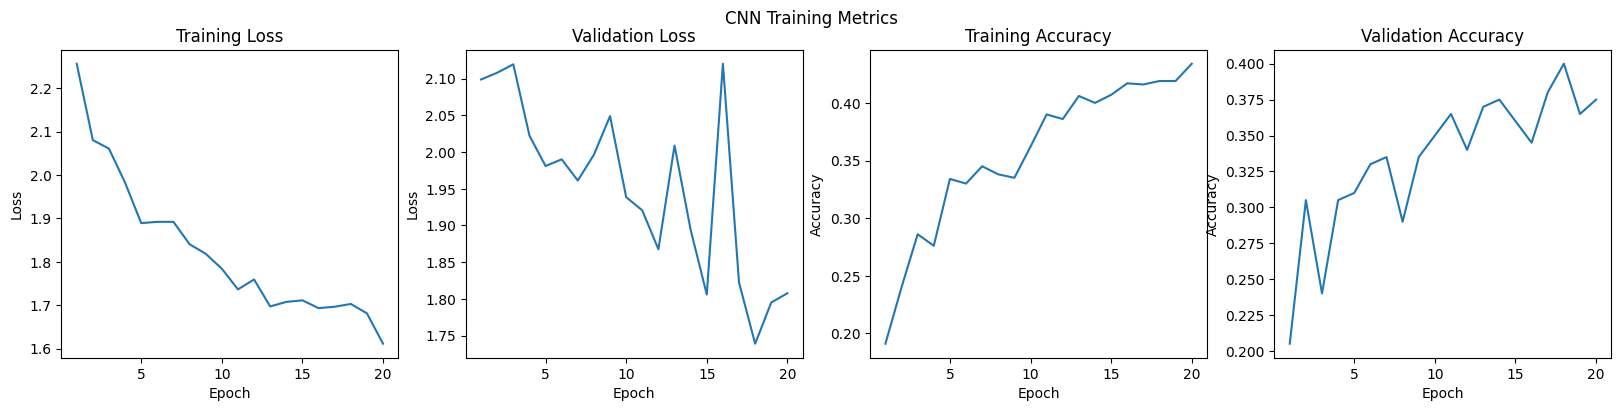

In [131]:
def plot_metrics(train_losses, val_losses, train_accuracies=None, val_accuracies=None, num_epochs=None, title=""):
    """
    Plots the training loss, training accuracy, validation loss, and validation accuracy.
    Args:
        train_losses: list of training losses
        val_losses: list of validation losses
        train_accuracies: list of training accuracies
        val_accuracies: list of validation accuracies
        num_epochs: number of epochs
        title: title of the plot
    """

    has_accuracies = train_accuracies and val_accuracies

    num_plots = 4 if has_accuracies else 2

    epochs = range(1, (num_epochs or len(train_losses)) + 1)

    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 4))
    fig.suptitle(title)

    axes[0].plot(epochs, train_losses)
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(epochs, val_losses)
    axes[1].set_title("Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")

    if has_accuracies:
        axes[2].plot(epochs, train_accuracies)
        axes[2].set_title("Training Accuracy")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Accuracy")

        axes[3].plot(epochs, val_accuracies)
        axes[3].set_title("Validation Accuracy")
        axes[3].set_xlabel("Epoch")
        axes[3].set_ylabel("Accuracy")

plot_metrics(cnn_train_losses, cnn_val_losses, cnn_train_accuracies, cnn_val_accuracies, num_epochs=20, title="CNN Training Metrics")

# Part 2: ResNet-18

Plain deep networks suffer from vanishing gradients as depth increases. ResNet fixes this with skip connections — each residual block adds its input directly to its output, keeping gradients flowing backward through the network.

## Residual Block

Implementing a residual block with the following architecture:

- Conv → BatchNorm → ReLU → Conv → BatchNorm → skip connection → ReLU

The skip connection adds the input directly to the output, allowing gradients to flow backward without shrinking. When the number of channels changes (downsampling), a 1×1 convolution projects the input to match dimensions.

In [132]:
class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        initial_downsample=False, # whether to downsample the input
        verbose=False, # whether to print debug statements
    ):
        super().__init__()
        self.verbose = verbose


        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels,kernel_size=3,padding=1,stride=2 if initial_downsample else 1)
        self.batchnorm1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels,kernel_size=3,padding=1,stride=1)
        self.batchnorm2 = nn.BatchNorm2d(out_channels)
        self.residual_connection = nn.Conv2d(in_channels=in_channels, out_channels=out_channels,kernel_size=1,stride=2) if initial_downsample else nn.Identity()

    def forward(self, x):
        conv1 = self.conv1(x)
        if self.verbose:
            print(f"conv1 shape: {conv1.shape}")
        bn1 = self.batchnorm1(conv1)
        if self.verbose:
            print(f"bn1 shape: {bn1.shape}")
        z1 = F.relu(bn1)

        conv2 = self.conv2(z1)
        if self.verbose:
            print(f"conv2 shape: {conv2.shape}")
        bn2 = self.batchnorm2(conv2)
        if self.verbose:
            print(f"bn2 shape: {bn2.shape}")

        residual = self.residual_connection(x)
        if self.verbose:
            print(f"residual shape: {residual.shape}")


        # Don't forget to apply ReLU activation after adding the residual
        out = F.relu(bn2+residual)
        return out

### Shape check

`ResidualBlock(in_channels=3, out_channels=64, kernel_size=3, initial_downsample=True)` with input `(1, 3, 224, 224)`:

1. After conv1 (stride 2): `(1, 64, 112, 112)`
2. After conv2 (stride 1): `(1, 64, 112, 112)`
3. Skip connection projection (1×1 conv, stride 2): `(1, 64, 112, 112)`
4. After addition + ReLU: `(1, 64, 112, 112)`

In [133]:
x = torch.rand((1, 3, 224, 224))  # 1 image, 3 RGB channels, 224 x 224 pixels
print(f"Shape of input: {x.shape}")

res = ResidualBlock(in_channels=3, out_channels=64, kernel_size=3, initial_downsample=True, verbose=False)
resblock_out = res(x)
print(f"Shape of output: {resblock_out.shape}")
assert resblock_out.shape == torch.Size([1, 64, 112, 112]), f"Expected output shape (1, 64, 112, 112), but got {resblock_out.shape}"

Shape of input: torch.Size([1, 3, 224, 224])
Shape of output: torch.Size([1, 64, 112, 112])


In [134]:
# Verify the shapes of the weights
conv1_shape = res.conv1.weight.shape
print(f"Shape of conv1 weight: {conv1_shape}")
assert conv1_shape == torch.Size([64, 3, 3, 3]), f"Expected Conv1 weights to have shape (64, 3, 3, 3), but got {conv1_shape}"

conv2_shape = res.conv2.weight.shape
print(f"Shape of conv2 weight: {conv2_shape}")
assert conv2_shape == torch.Size([64, 64, 3, 3]), f"Expected Conv2 weights to have shape (64, 64, 3, 3), but got {conv2_shape}"

residual_shape = res.residual_connection.weight.shape
print(f"Shape of residual weight: {residual_shape}")
assert residual_shape == torch.Size([64, 3, 1, 1]), f"Expected residual connection to have shape (64, 3, 1, 1), but got {residual_shape}"

Shape of conv1 weight: torch.Size([64, 3, 3, 3])
Shape of conv2 weight: torch.Size([64, 64, 3, 3])
Shape of residual weight: torch.Size([64, 3, 1, 1])


## ResNet-18 Architecture

18-layer residual network:

- Initial 7×7 conv (64 channels, stride 2) → BatchNorm → ReLU → MaxPool  
- Stage 1: 2× ResidualBlock, 64 channels  
- Stage 2: 2× ResidualBlock, 128 channels, downsample  
- Stage 3: 2× ResidualBlock, 256 channels, downsample  
- Stage 4: 2× ResidualBlock, 512 channels, downsample  
- Global average pool → Linear(512, num_classes)

In [135]:
class ResNet18(nn.Module):
    def __init__(self, num_classes, verbose=False):

        # Hint: don't forget to call super().__init__() first!
        super().__init__()
        self.verbose = verbose

        # convolution layer

        self.cov1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2, padding=3)
        self.batchnorm1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # stage 1
        self.res1 = ResidualBlock(in_channels=64, out_channels=64, kernel_size=3)
        self.res2 = ResidualBlock(in_channels=64, out_channels=64, kernel_size=3)

        # stage 2
        self.res3 = ResidualBlock(in_channels=64, out_channels=128, kernel_size=3, initial_downsample=True)
        self.res4 = ResidualBlock(in_channels=128, out_channels=128, kernel_size=3)

        # stage 3
        self.res5 = ResidualBlock(in_channels=128, out_channels=256, kernel_size=3, initial_downsample=True)
        self.res6 = ResidualBlock(in_channels=256, out_channels=256, kernel_size=3)

        # stage 4
        self.res7 = ResidualBlock(in_channels=256, out_channels=512, kernel_size=3, initial_downsample=True)
        self.res8 = ResidualBlock(in_channels=512, out_channels=512, kernel_size=3)

        # classification head
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(in_features=512, out_features=num_classes)

    def forward(self, x):


        # convolution
        cov1 = self.cov1(x)
        bn1 = self.batchnorm1(cov1)
        z1 = F.relu(bn1)
        maxpool1 = self.maxpool1(z1)

        # stage 1
        res1 = self.res1(maxpool1)
        res2 = self.res2(res1)

        # stage 2
        res3 = self.res3(res2)
        res4 = self.res4(res3)

        # stage 3
        res5 = self.res5(res4)
        res6 = self.res6(res5)

        # stage 4
        res7 = self.res7(res6)
        res8 = self.res8(res7)

        # classification
        gap = self.gap(res8)
        flatten = self.flatten(gap)
        out = self.linear(flatten)


        return out

### Shape check

`ResNet18(num_classes=10)` with input `(1, 3, 224, 224)` → expected output: `(1, 10)`

In [136]:
x = torch.rand((1, 3, 224, 224))  # 1 image, 3 RGB channels, 224 x 224 pixels
print(f"Shape of input: {x.shape}")

resnet18 = ResNet18(num_classes=10, verbose=True)
resnet18_out = resnet18(x)
print(f"Shape of output: {resnet18_out.shape}")
assert resnet18_out.shape == torch.Size([1, 10]), f"Expected output shape (1, 10), but got {resnet18_out.shape}"


Shape of input: torch.Size([1, 3, 224, 224])
Shape of output: torch.Size([1, 10])


## Training ResNet-18

Training for 50 epochs with AdamW + CrossEntropyLoss. Targeting ~70% training accuracy, ~50% validation accuracy.

In [137]:
resnet = ResNet18(num_classes=10)

num_epochs = 50

optimizer = torch.optim.AdamW(resnet.parameters())

criterion = torch.nn.CrossEntropyLoss()


resnet_train_accuracies, resnet_train_losses, resnet_val_accuracies, resnet_val_losses = train(resnet, optimizer, criterion, num_epochs, train_dataloader, val_dataloader)

Initial validation loss: 16.1072
Initial validation accuracy: 0.1200


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]


Epoch 1 - Training accuracy: 0.193
Epoch 1 - Training loss: 74.931


Training Progress:   2%|▏         | 1/50 [00:11<09:29, 11.63s/it, train_loss=74.931, train_acc=0.193, val_loss=20.085, val_acc=0.220]

Epoch 1 - Validation accuracy: 0.220
Epoch 1 - Validation loss: 20.085

Epoch 2 - Training accuracy: 0.264
Epoch 2 - Training loss: 64.102


...

Epoch 48 - Validation accuracy: 0.665
Epoch 48 - Validation loss: 8.367

Epoch 49 - Training accuracy: 0.837
Epoch 49 - Training loss: 15.975


Training Progress:  98%|█████████▊| 49/50 [09:24<00:11, 11.44s/it, train_loss=15.975, train_acc=0.837, val_loss=8.488, val_acc=0.660]

Epoch 49 - Validation accuracy: 0.660
Epoch 49 - Validation loss: 8.488

Epoch 50 - Training accuracy: 0.841
Epoch 50 - Training loss: 16.338


Training Progress: 100%|██████████| 50/50 [09:35<00:00, 11.52s/it, train_loss=16.338, train_acc=0.841, val_loss=7.649, val_acc=0.710]

Epoch 50 - Validation accuracy: 0.710
Epoch 50 - Validation loss: 7.649


## ResNet Training Curves

Plotting training/validation loss and accuracy.

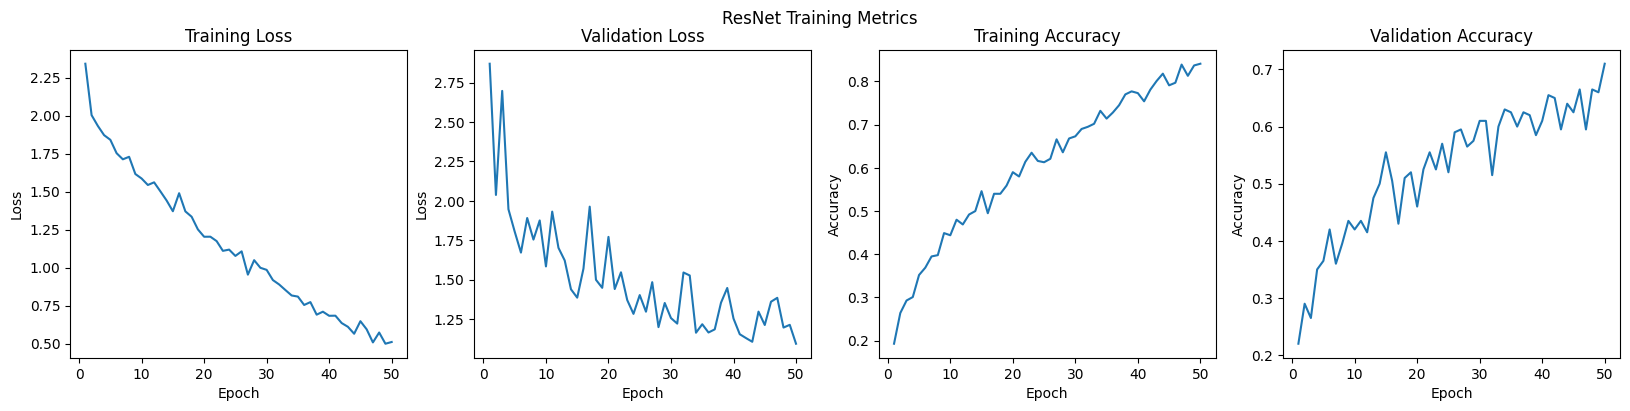

In [138]:
plot_metrics(resnet_train_losses, resnet_val_losses, resnet_train_accuracies, resnet_val_accuracies, num_epochs=50, title="ResNet Training Metrics")

# Part 3: Transformers

Building every Transformer component from scratch in PyTorch, then training a decoder-only model on TinyStories for next-token prediction.

## Softmax

Numerically stable softmax — subtracts `max(z)` before exponentiation to prevent overflow. Output values sum to 1 along the last dimension.

In [139]:
def softmax(x: torch.Tensor):
    """
    Compute the softmax of each element in x.
    """
    x = x - x.max(dim=-1, keepdim=True).values
    exp = torch.exp(x)
    sum = torch.sum(exp, dim=-1, keepdim=True)
    return exp / sum

Verifying output shape and values match PyTorch's built-in `F.softmax`.

In [140]:
set_seed(SEED)

rand_1d = torch.randn(5)
print(f"Random 1D vector with shape (d): {rand_1d.shape}")
out_1d = softmax(rand_1d)

print(f"Softmax output shape: {out_1d.shape}\nExpected shape: {rand_1d.shape}\n")

# Assert that the sum of the softmax output along the last dimension is 1
assert torch.allclose(torch.sum(out_1d, dim=-1), torch.ones_like(out_1d[..., 0]), rtol=1e-5), "Sum of softmax output along last dimension is not 1"

rand_3d = torch.randn(2, 5, 5)
print(f"Random vector with shape (B, N, N): {rand_3d.shape}")
out_3d = softmax(rand_3d)
print(f"Softmax output shape: {out_3d.shape}\nExpected shape: {rand_3d.shape}\n")

# Assert that the sum of the softmax output along the last dimension is 1
assert torch.allclose(torch.sum(out_3d, dim=-1), torch.ones_like(out_3d[..., 0]), rtol=1e-5), "Sum of softmax output along last dimension is not 1"

# Compare to torch implementation
torch_softmax_1d = torch.nn.functional.softmax(rand_1d, dim=-1)
assert torch.allclose(torch_softmax_1d, out_1d, rtol=1e-5), "Softmax implementation for 1D tensor does not match torch implementation"

torch_softmax_3d = torch.nn.functional.softmax(rand_3d, dim=-1)
assert torch.allclose(torch_softmax_3d, out_3d, rtol=1e-5), "Softmax implementation for 3D tensor does not match torch implementation"

Random 1D vector with shape (d): torch.Size([5])
Softmax output shape: torch.Size([5])
Expected shape: torch.Size([5])

Random vector with shape (B, N, N): torch.Size([2, 5, 5])
Softmax output shape: torch.Size([2, 5, 5])
Expected shape: torch.Size([2, 5, 5])



## Scaled Dot-Product Attention

$$Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Scaled by $\sqrt{d_k}$ to keep dot products from growing too large in high dimensions. Supports optional causal masking (upper-triangular) to prevent attending to future tokens.

In [141]:
def scaled_dot_product_attention(Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor, mask=None, verbose=False):
    """
    Q: matrix of shape (B, N, d_k)
    K: matrix of shape (B, N, d_k)
    V: matrix of shape (B, N, d_v)
    mask: boolean matrix of shape (B, N, N). Values where mask is True will be masked out

    B is the batch size
    N is the number of query/key/value vectors
    d_k is the dimensions of the query/key vectors
    d_v is the dimensions of the value vectors
    """
    assert Q.shape[-1] == K.shape[-1], "Q and K must have same d_k dimension"
    assert K.shape[-2] == V.shape[-2], "K and V must have same sequence length"


    prod = (Q @ K.transpose(-2, -1)) / np.sqrt(Q.shape[-1])
    if mask is not None:
        prod = prod.masked_fill(mask, float('-inf'))

    return softmax(prod) @ V

Verifying output shape and values against PyTorch's `F.scaled_dot_product_attention`.

In [142]:
Q_tensor = torch.randn(2, 5, 10)
K_tensor = torch.randn(2, 5, 10)
V_tensor = torch.randn(2, 5, 5)

print(f"Shape of Q: {Q_tensor.shape}")
print(f"Shape of K: {K_tensor.shape}")
print(f"Shape of V: {V_tensor.shape}")

sdpa_output = scaled_dot_product_attention(Q_tensor, K_tensor, V_tensor)
print(f"Shape of output: {sdpa_output.shape}")
assert sdpa_output.shape == torch.Size([2, 5, 5]), f"Expected output shape (B, N, d_v) {Q_tensor.shape}, but got {sdpa_output.shape}"

# Test that implementation is equal to torch implementation
torch_sdp = torch.nn.functional.scaled_dot_product_attention(
    Q_tensor, K_tensor, V_tensor, attn_mask=None
)
assert torch.allclose(sdpa_output, torch_sdp, rtol=1e-5), "Scaled dot product attention implementation does not match torch implementation"

Shape of Q: torch.Size([2, 5, 10])
Shape of K: torch.Size([2, 5, 10])
Shape of V: torch.Size([2, 5, 5])
Shape of output: torch.Size([2, 5, 5])


## Attention Head

Single attention head with learned linear projections for Q, K, and V. Supports self-attention and cross-attention.

In [143]:
class AttentionHead(nn.Module):
    def __init__(self, d_model=512, d_k=64, verbose=False):

        # Don't forget to call super().__init__()!
        super().__init__()

        self.W_q = nn.Linear(d_model,d_k)
        self.W_k = nn.Linear(d_model,d_k)
        self.W_v = nn.Linear(d_model,d_k)

    def forward(self, x, encoder_output=None, mask=None):
        """
        x is the input to use for the queries, keys, and values
        encoder_output is the output from the encoder (used for cross-attention)
        mask is the mask to use for the attention
        """


        W_q = self.W_q(x)
        if encoder_output is not None:
            W_k = self.W_k(encoder_output)
            W_v = self.W_v(encoder_output)
        else:
            W_k = self.W_k(x)
            W_v = self.W_v(x)

        return scaled_dot_product_attention(W_q, W_k, W_v, mask=mask)



In [144]:
# Sanity check the shape of the Attention Head output
set_seed(SEED)
batch_size = 10
seq_len = 20
d_model = 512
d_k = 64

x = torch.rand((batch_size, seq_len, d_model))
print(f"Shape of x: {x.shape}")

ah = AttentionHead(d_model=d_model, d_k=d_k)

ah_out = ah(x)

print(f"Attention head output shape: {ah_out.shape}")

assert ah_out.shape == torch.Size([batch_size, seq_len, d_k]), f"Expected output shape (B, N, d_k) {batch_size, seq_len, d_k}, but got {ah_out.shape}"

Shape of x: torch.Size([10, 20, 512])
Attention head output shape: torch.Size([10, 20, 64])


## Multi-Head Attention

Runs `num_heads` attention heads in parallel, each projecting to a `d_k = d_model / num_heads` subspace. Outputs are concatenated and projected back to `d_model`.

In [145]:
class MultiHeadAttention(nn.Module):
    def __init__(
        self,
        num_heads=8,
        d_model=512,  # dimension of the embeddings
        verbose=False,
    ):
        """
        Args:
            num_heads: number of attention heads
            d_model: dimension of the embeddings
            verbose: whether to print debug information
        """

        super().__init__()
        self.d_k = d_model // num_heads
        self.heads = nn.ModuleList([AttentionHead(d_model=d_model, d_k=self.d_k, verbose=verbose) for _ in range(num_heads)])
        self.linear = nn.Linear(d_model, d_model)


    def forward(self, x, encoder_output=None, mask=None):

        heads = [head(x, encoder_output=encoder_output, mask=mask) for head in self.heads]
        concat = torch.cat(heads, dim=-1)
        return self.linear(concat)


In [146]:
# Sanity check the shape of the Multi-Head Attention output
set_seed(SEED)
batch_size = 10
seq_len = 20
d_model = 512
num_heads = 8

x = torch.rand((batch_size, seq_len, d_model))
print(f"Shape of x: {x.shape}")

mhsa = MultiHeadAttention(num_heads=num_heads, d_model=d_model, verbose=False)

mhsa_out = mhsa(x)

print(f"Shape of Multi-Head Attention output: {mhsa_out.shape}")

assert mhsa_out.shape == torch.Size([batch_size, seq_len, d_model]), f"Expected output shape (B, N, d_model) {batch_size, seq_len, d_model}, but got {mhsa_out.shape}"

Shape of x: torch.Size([10, 20, 512])
Shape of Multi-Head Attention output: torch.Size([10, 20, 512])


## Encoder Layer

Self-attention → residual + LayerNorm → FFN (Linear → ReLU → Linear) → residual + LayerNorm. Produces context-rich representations of the input sequence.

In [147]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model=512, num_heads=8, verbose=False):

        super().__init__()

        self.multi_head_attention = MultiHeadAttention(num_heads=num_heads, d_model=d_model, verbose=verbose)
        self.ffn1 = nn.Linear(d_model, 4* d_model)
        self.ffn2 = nn.Linear(4 * d_model, d_model)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):

        # 1. Self-attention
        multi_head_attention = self.multi_head_attention(x)

        # 2. Residual connection
        residual1 = multi_head_attention + x

        # 3. LayerNorm
        layer_norm1 = self.layer_norm1(residual1)

        # 4. Feedforward network
        ffn1 = self.ffn1(layer_norm1)
        relu = F.relu(ffn1)
        ffn2 = self.ffn2(relu)


        # 5. Residual connection
        residual2 = ffn2 + layer_norm1

        # 6. LayerNorm
        layer_norm2 = self.layer_norm2(residual2)

        # 7. Return the output
        return layer_norm2

In [148]:
# Sanity check the shape of the EncoderLayer output
set_seed(SEED)
batch_size = 10
seq_len = 20
d_model = 512
num_heads = 8

x = torch.rand((batch_size, seq_len, d_model)) # (B, N, d_model)
print(f"Shape of x: {x.shape}")

encoder = EncoderLayer(d_model=d_model, num_heads=num_heads, verbose=False)

encoder_out = encoder(x)

print(f"Shape of encoder layer output: {encoder_out.shape}")

assert encoder_out.shape == torch.Size([batch_size, seq_len, d_model]), f"Expected output shape (B, N, d_model) {batch_size, seq_len, d_model}, but got {encoder_out.shape}"

Shape of x: torch.Size([10, 20, 512])
Shape of encoder layer output: torch.Size([10, 20, 512])


## Decoder Layer

Extends the encoder layer with two changes:
- **Masked self-attention** — causal look-ahead mask prevents attending to future positions
- **Cross-attention** — attends to encoder output (skipped in decoder-only mode when `encoder_output=None`)

In [149]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model=512, num_heads=8, verbose=False):

        super().__init__()
        self.mha1 = MultiHeadAttention(num_heads=num_heads, d_model=d_model, verbose=verbose)
        self.mha2 = MultiHeadAttention(num_heads=num_heads, d_model=d_model, verbose=verbose)
        self.ffn1 = nn.Linear(d_model, 4 * d_model)
        self.ffn2 = nn.Linear(4 * d_model, d_model)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output):


        # Create a look-ahead mask
        mask = torch.triu(torch.ones(x.shape[1], x.shape[1]), diagonal=1).bool().to(x.device)

        # 1. Masked self-attention
        mha1 = self.mha1(x, mask=mask)

        # 2. Residual connection
        residual1 = mha1 + x

        # 3. LayerNorm
        layer_norm1 = self.ln1(residual1)

        # 4. Cross-attention (if encoder_output is not None)
        if encoder_output is not None:
          mha2 = self.mha2(
              layer_norm1, encoder_output=encoder_output
              )

        # 5. Residual connection
          residual2 = mha2 + layer_norm1

        # 6. LayerNorm
          layer_norm2 = self.ln2(residual2)
        else:
          layer_norm2 = layer_norm1
        # 7. Position-wise feed forward network
        ffn1 = self.ffn1(layer_norm2)
        relu = F.relu(ffn1)
        ffn2 = self.ffn2(relu)

        # 8. Residual connection
        residual3 = ffn2 + layer_norm2

        # 9. LayerNorm
        layer_norm3 = self.ln3(residual3)

        # 10. Return the final normalized output
        return layer_norm3

In [150]:
# Sanity check the shape of the DecoderLayer output
set_seed(SEED)
batch_size = 10
seq_len = 20
d_model = 512
num_heads = 8

x = torch.rand((batch_size, seq_len, d_model)) # (B, N, d_model)
print(f"Shape of x: {x.shape}")

print("=" * 50)

encoder = EncoderLayer(d_model=d_model, num_heads=num_heads, verbose=True)
encoder_output = encoder(x)

print(f"Shape of encoder layer output: {encoder_output.shape}")

print("=" * 50)

decoder = DecoderLayer(d_model=d_model, num_heads=num_heads, verbose=True)
decoder_output = decoder(x, encoder_output)

print(f"Shape of decoder layer output: {decoder_output.shape}")

assert decoder_output.shape == torch.Size([batch_size, seq_len, d_model]), f"Expected output shape (B, N, d_model) {batch_size, seq_len, d_model}, but got {decoder_output.shape}"

Shape of x: torch.Size([10, 20, 512])
Shape of encoder layer output: torch.Size([10, 20, 512])
Shape of decoder layer output: torch.Size([10, 20, 512])


## Positional Encoding

Adds sinusoidal position signals to token embeddings using sin/cos waves at different frequencies, allowing the model to distinguish token order.

In [151]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024):
        """
        max_len = max number of tokens in the sequence
        """
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        divterm = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * divterm)
        pe[:, 1::2] = torch.cos(position * divterm)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe',pe)

    def forward(self, x):
        """
        Input x is of shape (B, seq_len, d_embedding)
        """
        x = x + self.pe[:, :x.shape[1]]
        return x

In [152]:
# Sanity check the shape of the PositionalEncoding output
set_seed(SEED)
pe = PositionalEncoding(512, max_len=1024)

input = torch.rand((10, 12, 512))
print(f"Shape of input: {input.shape}")

pe_output = pe(input)

print(f"Shape of positional encoding output: {pe_output.shape}")

assert pe_output.shape == input.shape, f"Expected output shape to have the same shape as the input {input.shape}, but got {pe_output.shape}"

Shape of input: torch.Size([10, 12, 512])
Shape of positional encoding output: torch.Size([10, 12, 512])


## TransformerEncoder

Embedding layer + positional encoding + stack of `EncoderLayer`s.

In [153]:
class TransformerEncoder(nn.Module):
    def __init__(
        self, vocab_size=1024, d_model=512, num_layers=6, num_heads=8, verbose=False
    ):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model=d_model, num_heads=num_heads, verbose=verbose)
            for _ in range(num_layers)
        ])

    def forward(self, x):

        # 1. Embed the input sequence of tokens
        x = self.embedding(x)

        # 2. Add positional encodings
        x = self.positional_encoding(x)

        # 3. Sequentially pass the result through each EncoderLayer
        for layer in self.layers:
            x = layer(x)

        # 4. Return the final tensor
        return x

In [154]:
# Sanity check the shape of the TransformerEncoder output
set_seed(SEED)

transformer_encoder = TransformerEncoder(vocab_size=1024, d_model=512, num_layers=6, num_heads=8, verbose=True)

# Randomly generate a batch of token IDs with shape (B, num_tokens)
input = torch.randint(low=0, high=1024, size=(10, 100)) # (B, num_tokens)

transformer_encoder_output = transformer_encoder(input)

print(f"Shape of transformer encoder output: {transformer_encoder_output.shape}")

assert transformer_encoder_output.shape == torch.Size([10, 100, 512]), f"Expected output shape (B, num_tokens, d_model) {(10, 100, 512)}, but got {transformer_encoder_output.shape}"

Shape of transformer encoder output: torch.Size([10, 100, 512])


## TransformerDecoder

Embedding layer + positional encoding + stack of `DecoderLayer`s + linear projection to vocabulary logits.

In [155]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size=1024, d_model=512, num_layers=6, num_heads=8, verbose=False):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model=d_model, num_heads=num_heads, verbose=verbose)
            for _ in range(num_layers)
        ])
        self.linear = nn.Linear(d_model, vocab_size)

    def forward(self, x, encoder_output):

        # 1. Embed the input sequence of tokens
        x = self.embedding(x)

        # 2. Add positional encodings
        x = self.positional_encoding(x)

        # 3. Sequentially pass the result through each DecoderLayer
        for layer in self.layers:
            x = layer(x, encoder_output)

        # 4. Apply the linear layer to predict the next token in our vocabulary
        x = self.linear(x)
        # 5. Return the final tensor
        return x

In [156]:
# Sanity check the shape of the TransformerDecoder output
set_seed(SEED)
transformer_decoder = TransformerDecoder(vocab_size=1024, d_model=512, num_layers=6, num_heads=8, verbose=True)

# Randomly generate a batch of token IDs with shape (B, num_tokens) to use as the target sequence we pass into the decoder
input = torch.randint(low=0, high=1024, size=(10, 100)) # (B, num_tokens)

# Randomly generate a batch of encoder outputs with shape (B, num_tokens, d_model)
encoder_output = torch.rand((10, 100, 512)) # (B, num_tokens, d_model)

# Pass the target sequence and encoder outputs through the decoder
transformer_decoder_output = transformer_decoder(input, encoder_output)

print(f"Shape of transformer decoder output: {transformer_decoder_output.shape}")

assert transformer_decoder_output.shape == torch.Size([10, 100, 1024]), f"Expected output shape (B, num_tokens, vocab_size) {(10, 100, 1024)}, but got {transformer_decoder_output.shape}"

Shape of transformer decoder output: torch.Size([10, 100, 1024])


## Full Transformer

Combines encoder and decoder. With `decoder_only=True`, passes input only through the decoder — used for text generation.

In [157]:
class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size=1024,
        d_model=512,
        num_encoder_layers=6,
        num_decoder_layers=6,
        num_heads=8,
        verbose=False,
        decoder_only=True
    ):

        super().__init__()
        self.decoder_only = decoder_only
        self.encoder = TransformerEncoder(vocab_size=vocab_size, d_model=d_model, num_layers=num_encoder_layers, num_heads=num_heads, verbose=verbose)
        self.decoder = TransformerDecoder(vocab_size=vocab_size, d_model=d_model, num_layers=num_decoder_layers, num_heads=num_heads, verbose=verbose)

    def forward(self, x):

        # 1. Pass `x` through the decoder if decoder_only
        if self.decoder_only:
            return self.decoder(x, encoder_output=None)

        # 2. Otherwise, forward pass through full encoder-decoder architecture
        # First, pass `x` through the encoder
        else:
            encoder_output = self.encoder(x)
        # 3. Pass `x` and the encoder's output through the decoder
        decoder_output = self.decoder(x, encoder_output)
        # 4. Return the output of the decoder
        return decoder_output

In [158]:
# Sanity check the shape of the Transformer output
set_seed(SEED)

transformer = Transformer(
    vocab_size=1024,
    d_model=512,
    num_encoder_layers=6,
    num_decoder_layers=6,
    num_heads=8,
    verbose=True,
)

# Randomly generate a batch of token IDs with shape (B, num_tokens)
input = torch.randint(low=0, high=1024, size=(10, 100))  # (B, num_tokens)

# Pass the input through the transformer
transformer_output = transformer(input)

print(f"Shape of transformer output: {transformer_output.shape}")

assert transformer_output.shape == torch.Size([10, 100, 1024]), f"Expected output shape (B, num_tokens, vocab_size) {(10, 100, 1024)}, but got {transformer_output.shape}"

Shape of transformer output: torch.Size([10, 100, 1024])


## TinyStories Dataset

Loading a small subset of the [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) dataset for training. Attribution: Eldan & Li (2023).

In [159]:
tiny_stories = load_dataset("roneneldan/TinyStories", split='train')
tiny_stories_small = tiny_stories.shuffle(seed=SEED).select(range(1000))
print(tiny_stories_small)

Dataset({
    features: ['text'],
    num_rows: 1000
})


Sample story from the dataset:

In [160]:
print(tiny_stories_small[0]['text'])

Tim and Mia like to play in the park. They see a big club on the ground. It is brown and long and heavy.

"Look, a club!" Tim says. "I can lift it!"

He tries to lift the club, but it is too tough. He falls down and drops the club.

"Ouch!" he says. "That hurt!"

Mia laughs. She is not mean, she just thinks it is funny.

"Let me try!" she says. "I can balance it!"

She picks up the club and puts it on her head. She walks slowly and carefully. She does not fall down.

"Wow!" Tim says. "You are good at balancing!"

"Thank you!" Mia says. "It is fun!"

They take turns balancing the club on their heads, arms, and legs. They have a lot of fun with the club. They are happy and proud. They are good friends.


Preprocessing: lowercase all stories, extract words, build a vocabulary dictionary (`word_to_id`). Special tokens added for `<start>`, `<end>`, and `<pad>`.

In [161]:
# Convert all the short stories to lowercase and collect them into a list
tiny_stories_text = [story['text'].lower() for story in tiny_stories_small]

# Extract all full words from text
def extract_full_words(text):
    """
    Given a string, extracts full words from the string
    Example:
        text = "The cat in the hat category"
        output = ['The', 'cat', 'in', 'the', 'hat', 'category']
    """
    pattern = r'\b\w+\b'
    return re.findall(pattern, text)

# Tokenize tiny story text - word level
paragraphs = []
for story in tiny_stories_text:
    story_paragraphs = story.split("\n\n") # split to remove new lines
    paragraphs.extend(story_paragraphs)

vocab = set()
for paragraph in paragraphs:
    full_words = extract_full_words(paragraph.lower())
    vocab.update(full_words)

word_to_id = {word: i for i, word in enumerate(vocab)}

PAD_TOKEN = '<pad>'
START_TOKEN = '<start>'
END_TOKEN = '<end>'

word_to_id[PAD_TOKEN] = len(vocab)
word_to_id[START_TOKEN] = len(vocab) + 1
word_to_id[END_TOKEN] = len(vocab) + 2

vocab.update([PAD_TOKEN, START_TOKEN, END_TOKEN])

print(vocab)
print(f"Vocab size: {len(vocab)}")

print(f"Token ID of 'park': {word_to_id['park']}")
print(f"Token ID of 'wizard': {word_to_id['wizard']}")
print(f"Token ID of 'cat': {word_to_id['cat']}")
print(f"Token ID of 'dog': {word_to_id['dog']}")


{'aroma', 'toolbox', 'pay', 'said', 'teaching', 'if', 'sky', 'amen', 'anytime', 'rufus', 'sidewalk', 'hole', 'fireplace', 'grassy', 'expression', 'naughty', 'waffle', 'repair', 'attic', 'blow', 'forgave', 'working', 'flag', 'marker', 'stretches', 'chews', 'ladle', 'wires', 'rubbing', 'smaller', 'low', 'baked', 'receiver', 'returning', 'funniest', 'cards', 'performed', 'crack', 'having', 'unpause', 'surroundings', 'helicopter', 'pretending', 'might', 'sounding', 'lids', 'helper', 'out', 'lunchbox', 'seahorse', 'forget', 'provided', 'replace', 'monster', 'dolphins', 'hairdresser', 'sammy', 'tape', 'tiny', 'square', 'organized', 'behavior', 'grace', 'plain', 'toys', 'watering', 'grill', 'trusty', 'mattered', 'lapped', 'lunch', 'fine', 'finally', 'were', 'dictionary', 'wandered', 'cheating', 'animals', 'dropping', 'they', 'rink', 'case', 'disappointed', 'addition', 'stretched', 'urge', 'mailbox', 'introduce', 'same', 'annabelle', 'examine', 'says', 'outside', 'either', 'raincoats', 'stretc

## Input/Target Sequences

For next-token prediction, inputs and targets are the same sequence shifted by one position:

```
input:  [<start>, "the", "cat", "sat"]
target: ["the",   "cat", "sat", <end>]
```

Sequences shorter than `max_seq_length` are skipped.

In [162]:
def create_sequences(stories, word_to_id, max_seq_length=20, pad_token=PAD_TOKEN, start_token=START_TOKEN, end_token=END_TOKEN):
    """
    Create input/target sequences from paragraphs

    Args:
        stories (list): List of stories to create sequences from
        word_to_id (dict): Dictionary mapping words to their token IDs
        max_seq_length (int): Maximum sequence length to create
        pad_token (str): Token for the pad token
        start_token (str): Token for the start of a sequence
        end_token (str): Token for the end of a sequence

    Returns:
        inputs (tensor): Tensor of input sequences
        targets (tensor): Tensor of target sequences
    """
    inputs = []
    targets = []

    # List of paragraphs
    paragraphs = []

    for story in stories:
      for paragraph in story.split("\n\n"):
        paragraph = paragraph.strip()
        if paragraph:
            paragraphs.append(paragraph)


    # Make sure to skip paragraphs that are too short to create any sequences
    for paragraph in paragraphs:
      words = paragraph.split()
      tokens = [start_token] + words + [end_token]
      ids = [word_to_id[word] for word in tokens if word in word_to_id]

      for i in range(len(ids) - 1):
        input_seq = ids[i:i+max_seq_length]
        target_seq = ids[i+1:i+max_seq_length+1]
        if len(input_seq) < 2:
          continue

        input_seq = input_seq + [word_to_id[pad_token]] * (max_seq_length - len(input_seq))
        target_seq = target_seq + [word_to_id[pad_token]] * (max_seq_length - len(target_seq))

        inputs.append(input_seq)
        targets.append(target_seq)

    inputs = torch.tensor(inputs, dtype=torch.long)
    targets = torch.tensor(targets, dtype=torch.long)
    return inputs, targets

# Generate sequences
max_seq_length = 20
inputs, targets = create_sequences(tiny_stories_text, word_to_id, max_seq_length)

print(f"Total sequences created: {len(inputs)}")
print(f"Each input sequence length: {len(inputs[0])}")
print(f"Each target sequence length: {len(targets[0])}")

Total sequences created: 149646
Each input sequence length: 20
Each target sequence length: 20


## Training and Validation DataLoaders

Splitting sequences 80/20 into train/val sets. Using 2,000 training samples and 200 validation samples to keep memory manageable. DataLoaders with `batch_size=32`.

In [163]:
split_data = int(0.8 * len(inputs))

train_inputs = inputs[:split_data]
train_targets = targets[:split_data]
val_inputs = inputs[split_data:]
val_targets = targets[split_data:]

print(f"Number of training sequences: {len(train_inputs)}")
print(f"Number of validation sequences: {len(val_inputs)}")

train_dataset = TensorDataset(train_inputs[:2000], train_targets[:2000])
val_dataset = TensorDataset(val_inputs[:200], val_targets[:200])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

batch = next(iter(train_loader)) # Get the first batch from the training DataLoader

train_input, train_target = batch # Unpack the batch into input and target tensors
print(f"First 10 tokens of training input in first batch: {train_input[0][:10]}")
print(f"First 10 tokens of training target in first batch: {train_target[0][:10]}")

Number of training sequences: 119716
Number of validation sequences: 29930
Training batches: 63
Validation batches: 7
First 10 tokens of training input in first batch: tensor([3157, 3311, 3567, 3409, 3519, 4440,  570, 1962,  748, 1448])
First 10 tokens of training target in first batch: tensor([3311, 3567, 3409, 3519, 4440,  570, 1962,  748, 1448, 2667])


## Training the Transformer

Decoder-only Transformer with `d_model=128`, 2 layers, 4 attention heads. Trained with AdamW (lr=2e-4) and CrossEntropyLoss.

In [164]:
# Transformer training loop
def train_transformer(
    model,
    device,
    optimizer,
    criterion,
    num_epochs,
    train_dataloader,
    val_dataloader,
    vocab,
):
    # === SETUP ===
    # Move model to device
    model.to(device)

    # Lists to store metrics across epochs
    train_losses = []
    val_losses = []

    # === EPOCH LOOP ===
    for epoch in tqdm(range(num_epochs)):
        # === TRAINING PHASE ===
        model.train()  # Set model to training mode

        # Initialize metrics for this epoch
        total_train_loss = 0.0

        # === INNER LOOP (iterate over training batches) ===
        for batch_inputs, batch_targets in tqdm(train_dataloader, desc="Training"):
            # Move inputs and targets to device
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            # Reset the gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(batch_inputs)  # [batch_size, seq_len, vocab_size]

            # Reshape for loss calculation
            loss = criterion(logits.reshape(-1, len(vocab)), batch_targets.reshape(-1))
            # Compute loss
            loss.backward()

            # Optional: Add gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update the model parameters
            optimizer.step()

            # Accumulate the loss
            total_train_loss += loss.item()

        # === END OF INNER LOOP ===

        # Compute the average loss for this epoch
        avg_train_loss = total_train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        # === END OF TRAINING PHASE ===

        # === VALIDATION PHASE ===
        model.eval()  # Set model to evaluation mode
        total_val_loss = 0.0

        with torch.no_grad():
            # === INNER LOOP (iterate over validation batches) ===
            for batch_inputs, batch_targets in tqdm(val_dataloader, desc="Validation"):
                # Move inputs and targets to device
                batch_inputs = batch_inputs.to(device)
                batch_targets = batch_targets.to(device)

                # Forward pass
                logits = model(batch_inputs)

                # Compute loss
                loss = criterion(
                    logits.reshape(-1, len(vocab)), batch_targets.reshape(-1)
                )

                # Accumulate the loss
                total_val_loss += loss.item()
        # === END OF INNER LOOP ===

        # Compute the average loss for this epoch
        avg_val_loss = total_val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)

        # === END OF VALIDATION PHASE ===

        # Print epoch results
        print(f"\nEpoch {epoch + 1} Results:")
        print(f"  Training Loss: {avg_train_loss:.4f}")
        print(f"  Validation Loss: {avg_val_loss:.4f}")

    # === END OF EPOCH LOOP ===

    return train_losses, val_losses

In [165]:
transformer = Transformer(vocab_size=len(vocab), d_model=128, num_encoder_layers=2, num_decoder_layers=2, num_heads=4, decoder_only=True)

optimizer = torch.optim.AdamW(transformer.parameters(), lr=2e-4)

criterion = nn.CrossEntropyLoss()

num_epochs = 10

transformer_train_losses, transformer_val_losses = train_transformer(
    model=transformer,
    device=device,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=num_epochs,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    vocab=vocab
)

Training: 100%|██████████| 63/63 [00:01<00:00, 49.62it/s]

 10%|█         | 1/10 [00:01<00:11,  1.32s/it]


Epoch 1 Results:
  Training Loss: 5.6472
  Validation Loss: 5.3147



Training: 100%|██████████| 63/63 [00:01<00:00, 53.29it/s]

 20%|██        | 2/10 [00:02<00:10,  1.27s/it]


Epoch 2 Results:
  Training Loss: 3.6493
  Validation Loss: 4.6944



Training: 100%|██████████| 63/63 [00:01<00:00, 46.88it/s]

 30%|███       | 3/10 [00:03<00:09,  1.33s/it]

...


Epoch 8 Results:
  Training Loss: 1.1194
  Validation Loss: 5.0253



Training: 100%|██████████| 63/63 [00:01<00:00, 50.08it/s]

 90%|█████████ | 9/10 [00:12<00:01,  1.38s/it]


Epoch 9 Results:
  Training Loss: 0.9096
  Validation Loss: 5.0980



Training: 100%|██████████| 63/63 [00:01<00:00, 53.53it/s]

100%|██████████| 10/10 [00:14<00:00,  1.40s/it]


Epoch 10 Results:
  Training Loss: 0.7479
  Validation Loss: 5.1810


## Transformer Training Curves

Final Training Loss: 0.7479
Final Validation Loss: 5.1810


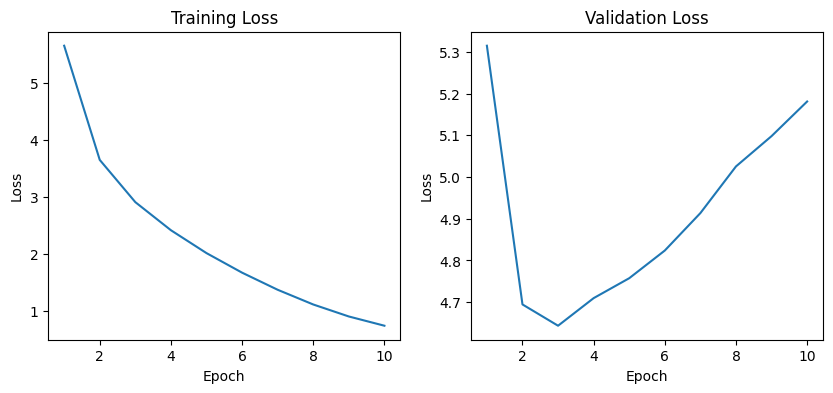

In [166]:
plot_metrics(transformer_train_losses,transformer_val_losses)

print(f"Final Training Loss: {transformer_train_losses[-1]:.4f}")
print(f"Final Validation Loss: {transformer_val_losses[-1]:.4f}")

Autoregressive generation from a prompt — the model predicts one token at a time, feeding each output back as input.

In [167]:
def generate_sample(model, word_to_id, id_to_word, max_seq_len=20, prompt="once upon a time", max_length=50):
    """
    Autoregressively generate a sample from the transformer

    Args:
        model (Transformer): The transformer model
        word_to_id (dict): Dictionary mapping words to their token IDs
        id_to_word (dict): Dictionary mapping token IDs to words
        max_seq_len (int): Maximum sequence length used when training the transformer
        prompt (str): The starting prompt for the generated story
        max_length (int): Maximum length of the generated story

    Returns:
        str: The generated story
    """
    model.eval()
    with torch.no_grad():
        tokens = [word_to_id.get(word, 0) for word in [word_to_id[START_TOKEN]] + prompt.split()]

        for _ in range(max_length):
            if len(tokens) >= max_seq_len:  # max sequence length used when training the transformer
                input_seq = torch.tensor([tokens[-1 * max_seq_len:]], dtype=torch.long, device=device)
            else:
                input_seq = torch.tensor([tokens], dtype=torch.long, device=device)

            logits = transformer(input_seq)
            next_token = torch.argmax(logits[0, -1]).item()
            tokens.append(next_token)

            if next_token == word_to_id.get(END_TOKEN, -1):
                break

        return ' '.join([id_to_word.get(token, '<unk>') for token in tokens])

id_to_word = {v: k for k, v in word_to_id.items()}


In [168]:
sample_text = generate_sample(
    model=transformer,
    word_to_id=word_to_id,
    id_to_word=id_to_word,
    max_seq_len=max_seq_length,
    prompt="frog",
    )
print(f"Sample generation: {sample_text}")

Sample generation: aroma frog and saw that she was very so she told lily to clean <end>
